Implementação de data augmentation para criar novas imagens de flores, já que ao treinar houve uma accuracy de 99%, logo overfitting. Ao aplicar evaluate a accuracy foi de aproximadamente 65%, logo para aumentar essa accuracy foi implementada data augmentation.

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL #Image library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, RandomZoom, RandomContrast, RandomRotation, RandomFlip

In [ ]:
dataset_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

In [ ]:
os.listdir('/root/.keras/datasets/flower_photos')

['flower_photos']

In [ ]:
data_dir = pathlib.Path(data_dir) / "flower_photos"
list(data_dir.glob('*/*.jpg'))
data_dir

PosixPath('/root/.keras/datasets/flower_photos/flower_photos')

In [ ]:
roses = list(data_dir.glob('roses/*'))

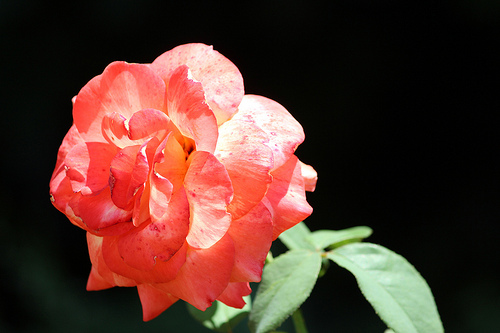

In [ ]:
PIL.Image.open(str(roses[2]))

In [ ]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,

}

array([[[ 14,  47,  68],
        [ 11,  42,  63],
        [ 11,  41,  60],
        ...,
        [  3,   8,   6],
        [  3,   8,   6],
        [  3,   8,   6]],

       [[ 17,  52,  76],
        [ 15,  47,  72],
        [ 15,  45,  70],
        ...,
        [  3,   8,   6],
        [  3,   8,   6],
        [  3,   8,   6]],

       [[ 15,  52,  79],
        [ 16,  50,  80],
        [ 15,  49,  79],
        ...,
        [  3,   8,   6],
        [  3,   8,   6],
        [  3,   8,   6]],

       ...,

       [[ 13,  19,  30],
        [ 13,  19,  30],
        [ 12,  19,  28],
        ...,
        [105, 146, 178],
        [108, 146, 178],
        [110, 148, 181]],

       [[  9,  17,  27],
        [ 10,  18,  28],
        [ 10,  18,  27],
        ...,
        [105, 145, 176],
        [105, 143, 176],
        [ 98, 145, 169]],

       [[ 10,  16,  26],
        [ 11,  18,  27],
        [ 10,  17,  26],
        ...,
        [105, 145, 174],
        [100, 139, 173],
        [ 80, 139, 150]]], dtype=uint8)
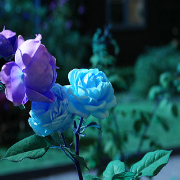

In [ ]:
img = cv2.imread(flowers_images_dict['roses'][0])
cv2.resize(img, (180, 180))

In [ ]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
  for image in images:
    img = cv2.imread(image)
    resized_img = cv2.resize(img, (180, 180))
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])


In [ ]:
X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
# Sempre dividimos valores RGB por 255 para escalar ele, ficar entre 0 e 1
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

In [ ]:
model = Sequential([
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')

])

In [ ]:
model.compile(optimizer='adam', loss=['sparse_categorical_crossentropy'], metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=12)

# Ocorre overfitting, accuracy: 99%

Epoch 1/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 716ms/step - accuracy: 0.3276 - loss: 1.5448
Epoch 2/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 59s 689ms/step - accuracy: 0.5949 - loss: 1.0234
Epoch 3/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 59s 686ms/step - accuracy: 0.6780 - loss: 0.8357
Epoch 4/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 692ms/step - accuracy: 0.7896 - loss: 0.6010
Epoch 5/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 59s 684ms/step - accuracy: 0.8727 - loss: 0.3817
Epoch 6/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 675ms/step - accuracy: 0.9254 - loss: 0.2364
Epoch 7/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 58s 673ms/step - accuracy: 0.9773 - loss: 0.1008
Epoch 8/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 58s 678ms/step - accuracy: 0.9861 - loss: 0.0583
Epoch 9/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 87s 734ms/step - accuracy: 0.9965 - loss: 0.0270
Epoch 10/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 705ms/step - accuracy: 0.9755 - loss: 0.0834
Epoch 11/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 740ms/step - accuracy: 0.9847 - loss: 0.0481
Epoch 12/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 85

In [ ]:
model.evaluate(X_test_scaled, y_test)


29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.6472 - loss: 2.1140


[2.055873394012451, 0.6546840667724609]

In [ ]:
predictions = model.predict(X_test_scaled)

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 306ms/step


In [ ]:
score = tf.nn.softmax(predictions[0])
print(int(np.argmax(score)), int(y_test[0]))

1 1


In [64]:
data_augmentation = keras.Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [65]:
model = Sequential([
    data_augmentation,
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')

])

In [66]:
model.compile(optimizer='adam', loss=['sparse_categorical_crossentropy'], metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=12)

Epoch 1/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 84s 918ms/step - accuracy: 0.3287 - loss: 1.5488
Epoch 2/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 74s 858ms/step - accuracy: 0.5674 - loss: 1.0925
Epoch 3/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 78s 812ms/step - accuracy: 0.6059 - loss: 0.9786
Epoch 4/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 69s 799ms/step - accuracy: 0.6420 - loss: 0.9351
Epoch 5/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 805ms/step - accuracy: 0.6902 - loss: 0.8351
Epoch 6/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 68s 791ms/step - accuracy: 0.6861 - loss: 0.8345
Epoch 7/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 784ms/step - accuracy: 0.7180 - loss: 0.7521
Epoch 8/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 68s 784ms/step - accuracy: 0.7290 - loss: 0.7105
Epoch 9/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 788ms/step - accuracy: 0.7601 - loss: 0.6709
Epoch 10/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 85s 825ms/step - accuracy: 0.7513 - loss: 0.6544
Epoch 11/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 69s 794ms/step - accuracy: 0.7530 - loss: 0.6414
Epoch 12/12
86/86 ━━━━━━━━━━━━━━━━━━━━ 82

In [67]:
model.evaluate(X_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - accuracy: 0.7162 - loss: 0.8312


[0.7966539859771729, 0.7026143670082092]